In [8]:
import pandas as pd
import bambi as bmb
import arviz as az
import arviz_plots as azp
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/fiodarzianiutsich/Desktop/projekt/data_cleaning/red_spruce_2022.csv')

Here we define our advanced hierarchical model. We account for the macroclimate (the county level) by allowing both the baseline height (intercept) and the growth rate (slope) to vary.


In [3]:
model_formula = "log_height ~ log_diameter + (log_diameter | county)"

model = bmb.Model(model_formula, df)

In [4]:
results = model.fit(target_accept=0.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, log_diameter, 1|county_sigma, 1|county_offset, log_diameter|county_sigma, log_diameter|county_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


In [5]:
tabel = az.summary(results)
tabel[tabel['r_hat'] > 1.05]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat


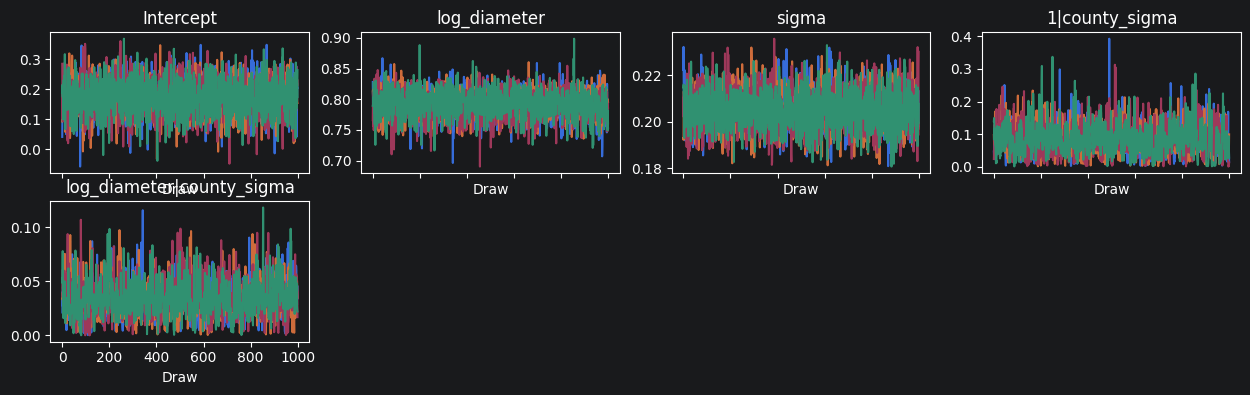

In [7]:
azp.plot_trace(results, var_names=['Intercept', 'log_diameter', 'sigma', '1|county_sigma', 'log_diameter|county_sigma'])